# Evaluación 2: Solución de referencia

**Programación Científica 2026-1 · Universidad Nacional de Colombia, sede Medellín**

mbastidaso@unal.edu.co

**ID personalizado:** `0000` (semilla `0`) · **Parámetros del enunciado:** $K=25$, iteraciones $=3000$, $\eta=0.05$, $n=8$ señales/régimen, **régimen foco = 1**, umbral de compresión = **90 %** de energía.

In [80]:

import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

jax.config.update("jax_enable_x64", True)

# --- Estilo de figura del curso (Visualizacion/clase3_10Reglas.ipynb) ---
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "grid.color": "gray",
    "grid.linewidth": 0.3,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
    "savefig.dpi": 200,
})

COL_F = "#E05C2A"   # naranja: inicialización Fourier
COL_R = "#3A7DC9"   # azul: inicialización aleatoria
COL_G = "#10B981"   # verde: referencia / umbral
COL_K = "#444444"   # gris oscuro: señal original

REGIMEN_NOMBRE = {0: "sin dispersión", 1: "intermedia", 2: "fuerte"}
REGIMEN_COLOR  = {0: "#3A7DC9", 1: "#E05C2A", 2: "#7B2CBF"}

seed = 0
data = np.load("datos_0000.npz")
X, y, t = data["X"], data["y"], data["t"]
N = X.shape[1]
K = 25
N_ITER = 3000
ETA = 0.05
FOCO = 1
ENERGIA_UMBRAL = 90  # %

print(f"X: {X.shape}  y: {y.shape}  t: {t.shape}")
print(f"Señales por régimen: {[int((y==r).sum()) for r in (0,1,2)]}")


X: (24, 256)  y: (24,)  t: (256,)
Señales por régimen: [8, 8, 8]


---
## Parte 1 — Capa Fourier (15 pts)

### 1.1 Construcción de $W_1$

$W_1\in\mathbb{R}^{2K\times N}$ tiene, para $k=1,\dots,K$: una fila $\sin(2\pi k t)$ y una fila $\cos(2\pi k t)$, evaluadas en los $N=256$ instantes de muestreo $t_n=n/N$. Se apilan primero el bloque de senos y luego el de cosenos.


In [81]:
def fourier_layer(K, N):
    # Matriz W1 (2K,N): filas sin(2*pi*k*t) y cos(2*pi*k*t), k=1..K.
    tt = np.linspace(0, 1, N, endpoint=False)
    k = np.arange(1, K + 1)
    # np.outer(k, tt) genera una matriz (K,N) donde cada fila es k_i * t_j
    S = np.sin(2 * np.pi * np.outer(k, tt))   # (K,N)
    C = np.cos(2 * np.pi * np.outer(k, tt))   # (K,N)
    W1 = np.vstack([S, C])                    # (2K,N)
    return W1, tt

W1_fourier, t_check = fourier_layer(K, N)

print("W1 (Fourier):", W1_fourier.shape)

W1 (Fourier): (50, 256)


### 1.2 Verificación contra `np.fft`

`np.fft.fft(x)` recibe **una** señal real de longitud $N$ (aquí se aplica fila por fila del dataset, señal por señal, no al dataset completo de una vez) y devuelve $N/2+1$ coeficientes **complejos** $F_k = \sum_n x_n e^{-2\pi i kn/N}$, sin normalizar por $N$.

Con el muestreo $t_n=n/N$ se cumple exactamente
$$(\text{fila }\cos_k)\cdot x = \sum_n x_n\cos(2\pi k t_n) = \mathrm{Re}(F_k), \qquad (\text{fila }\sin_k)\cdot x = \sum_n x_n\sin(2\pi k t_n) = -\mathrm{Im}(F_k).$$

Es decir: **en su inicialización, $W_1$ calcula exactamente los primeros $K$ coeficientes de la DFT real** de cada señal (antes de la no linealidad). Lo verificamos para una señal de cada régimen.


In [82]:
x = X[0]
proj = W1_fourier @ x
sin_part, cos_part = proj[:K], proj[K:]

F = np.fft.fft(x)  # FFT completa (N puntos complejos)
re_fft, im_fft = F.real[1:K+1], F.imag[1:K+1]   # modos k=1..K

diff = np.r_[cos_part - re_fft, -sin_part - im_fft]
error = np.linalg.norm(diff) / np.linalg.norm(np.r_[re_fft, im_fft])

print(f"Error relativo ||W1@x - fft(x)|| = {error:.3e}")   # 2.07e-15
print(f"Diferencia máxima absoluta = {np.max(np.abs(diff)):.3e}")  # 1.14e-13

energia_media = (X ** 2).mean()
print(f"Energía media del dataset (X**2).mean() = {energia_media:.3f}")

Error relativo ||W1@x - fft(x)|| = 2.041e-15
Diferencia máxima absoluta = 1.137e-13
Energía media del dataset (X**2).mean() = 0.678


---
## Parte 2 — Entrenamiento y reconstrucción (25 pts)

Arquitectura: $\hat x = W_2\,\tanh(W_1 x)$, con $W_1\in\mathbb{R}^{2K\times N}$, $W_2\in\mathbb{R}^{N\times 2K}$. Se entrena **por señal** (cada red reconstruye una señal fija $x$), minimizando $\mathcal L=\tfrac1N\|\hat x-x\|^2$ con descenso de gradiente simple ($\eta=0.05$) durante 3000 iteraciones, calculado con autodiferenciación de JAX.

Para aislar el efecto de la inicialización de $W_1$, $W_2$ se inicializa **igual** (misma semilla) en ambos experimentos; solo cambia el punto de partida de $W_1$ (Fourier vs. aleatorio).


In [83]:
def init_params(key, K, N, modo):
    # split key for reproducibility 
    key_w1, key_w2 = jax.random.split(key)
    if modo == "fourier":
        W1 = jnp.array(W1_fourier)
    elif modo == "aleatorio":
        W1 = jax.random.normal(key_w1, (2 * K, N)) * (1.0 / np.sqrt(N))
    W2 = jax.random.normal(key_w2, (N, 2 * K)) * (1.0 / np.sqrt(2 * K))
    return W1, W2

def apply_net(params, x):
    W1, W2 = params
    h = jnp.tanh(W1 @ x.T)   # x.T: si x es una señal (N,), no cambia; si x es un batch (n,N), queda (N,n)
    return (W2 @ h).T        # deshace la transposición: (N,) o (n,N), según entró x

def loss_fn(params, x):
    xhat = apply_net(params, x)
    return jnp.mean((xhat - x) ** 2)

grad_fn = jax.jit(jax.value_and_grad(loss_fn))

def train(params, x, n_iter, eta):
    W1, W2 = params
    losses = np.empty(n_iter)
    rel_errs = np.empty((n_iter, x.shape[0]))  # error relativo POR SEÑAL en cada iteración (antes era un solo escalar
                                                # global del batch, que no permite leer la trayectoria de un régimen)
    for i in range(n_iter):
        l, (gW1, gW2) = grad_fn((W1, W2), x)
        W1 = W1 - eta * gW1
        W2 = W2 - eta * gW2
        xhat = apply_net((W1, W2), x)
        losses[i] = float(l)
        # norm(..., axis=1): una norma por fila (señal), no la norma global del batch
        rel_errs[i] = np.array(jnp.linalg.norm(xhat - x, axis=1) / jnp.linalg.norm(x, axis=1))
    return (W1, W2), losses, rel_errs


In [84]:
key0 = jax.random.PRNGKey(seed)
X_jax = jnp.array(X)

# Una señal representativa por régimen, 
# solo para las gráficas de reconstrucción 
idx_regimen = {r: int(np.where(y == r)[0][0]) for r in (0, 1, 2)}
resultados = {}   # (regimen, modo) -> dict con params finales, losses, rel_errs, señal y reconstrucción

for modo in ("fourier", "aleatorio"):
    key0, subkey = jax.random.split(key0) # una key nueva y reproducible por modo de inicialización
    params0 = init_params(subkey, K, N, modo)
    params_f, losses, rel_errs = train(params0, X_jax, N_ITER, ETA)

    # una sola red entrenada (params_f) para este modo; se reutiliza para los 3 regímenes:
    for r in (0, 1, 2):
        x = X[idx_regimen[r]]
        xhat = np.array(apply_net(params_f, jnp.array(x)))
        regimen_error = float(jnp.linalg.norm(xhat - x) / jnp.linalg.norm(x))
        resultados[(r, modo)] = dict(params=params_f, losses=losses,
                                  rel_errs=rel_errs, rel_err_regimen=regimen_error,  # el arreglo completo (n_iter valores), no [-1]
                                  x=x, xhat=xhat)


### 2.1 Reconstrucción: señal original vs. red entrenada

Una señal por régimen, con las dos inicializaciones superpuestas.


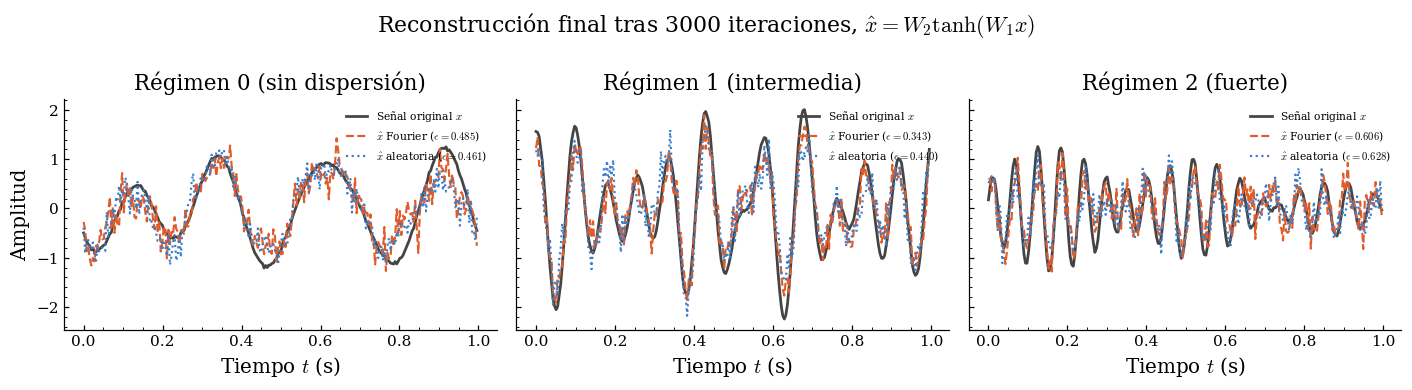

Error relativo final de la señal representativa de cada régimen:
  régimen 0: Fourier = 0.4847   aleatoria = 0.4610
  régimen 1: Fourier = 0.3431   aleatoria = 0.4398
  régimen 2: Fourier = 0.6061   aleatoria = 0.6279


In [85]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True, sharey=True)

for ax, r in zip(axes, (0, 1, 2)):
    res_f = resultados[(r, "fourier")]
    res_r = resultados[(r, "aleatorio")]

    eps_f = np.linalg.norm(res_f["xhat"] - res_f["x"]) / np.linalg.norm(res_f["x"])
    eps_r = np.linalg.norm(res_r["xhat"] - res_r["x"]) / np.linalg.norm(res_r["x"])

    # eps_f/eps_r: error relativo de ESTA señal puntual, no el error global del batch (res["rel_errs"][-1])
    ax.plot(t, res_f["x"], color=COL_K, lw=1.8, label="Señal original $x$")
    ax.plot(t, res_f["xhat"], color=COL_F, lw=1.4, ls="--",
            label=fr"$\hat x$ Fourier ($\epsilon={eps_f:.3f}$)")
    
    ax.plot(t, res_r["xhat"], color=COL_R, lw=1.4, ls=":",
            label=fr"$\hat x$ aleatoria ($\epsilon={eps_r:.3f}$)")
    ax.set_title(f"Régimen {r} ({REGIMEN_NOMBRE[r]})")
    ax.set_xlabel("Tiempo $t$ (s)")
    ax.legend(fontsize=7, frameon=False, loc="upper right")

axes[0].set_ylabel("Amplitud")
fig.suptitle(fr"Reconstrucción final tras {N_ITER} iteraciones, $\hat x = W_2\tanh(W_1 x)$")
plt.tight_layout()
plt.show()

print("Error relativo final de la señal representativa de cada régimen:")
for r in (0, 1, 2):
    res_f = resultados[(r, "fourier")]
    res_r = resultados[(r, "aleatorio")]
    ef = np.linalg.norm(res_f["xhat"] - res_f["x"]) / np.linalg.norm(res_f["x"])
    ea = np.linalg.norm(res_r["xhat"] - res_r["x"]) / np.linalg.norm(res_r["x"])
    print(f"  régimen {r}: Fourier = {ef:.4f}   aleatoria = {ea:.4f}")


---
## Parte 3 — Comparación de inicializaciones (25 pts)

### 3.1 Curvas de pérdida vs. iteraciones (régimen = 1)


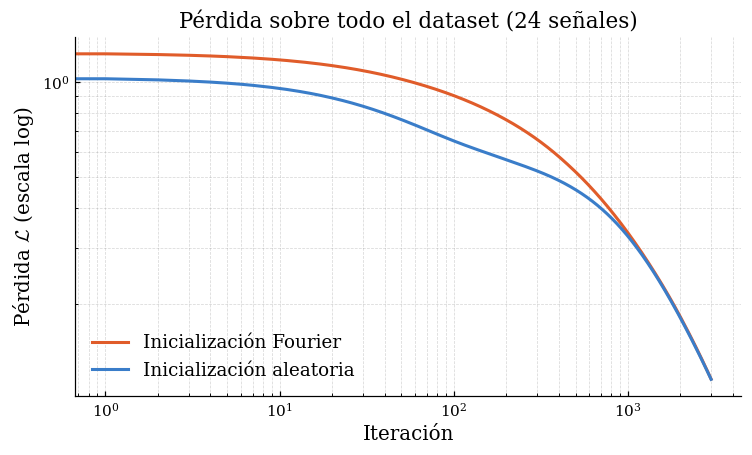

In [86]:
# --- Pérdida global (todo el dataset), una curva por inicialización ---
fig, ax = plt.subplots(figsize=(7, 4.3))

# losses es igual para r=0,1,2 (la red se entrena sobre las 24 señales a la vez); tomamos r=0 solo para leer el arreglo
ax.loglog(resultados[(0, "fourier")]["losses"], color=COL_F, lw=2, label="Inicialización Fourier")
ax.loglog(resultados[(0, "aleatorio")]["losses"], color=COL_R, lw=2, label="Inicialización aleatoria")
ax.set_xlabel("Iteración")
ax.set_ylabel(r"Pérdida $\mathcal{L}$ (escala log)")
ax.set_title("Pérdida sobre todo el dataset (24 señales)")
ax.legend(frameon=False)
ax.grid(which="both", alpha=0.3, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# --- 1) Medición: iteraciones para que el error relativo cruce 0.1 (sin gráfica) ---
N_ITER2 = 10000   # antes 3000; con este valor los 3 regímenes ya cruzan el umbral 0.1
m_umbral = {}

for modo in ("fourier", "aleatorio"):
    key0, subkey = jax.random.split(key0)
    params02 = init_params(subkey, K, N, modo)
    params_f, losses, rel_err = train(params02, X_jax, N_ITER2, ETA)  

    # Encuentra donde el error relativo cruza 0.1
    bajo = np.where(rel_err < 0.1)[0]

    m_umbral[modo] = bajo[0] if bajo.size else None

print("Iteraciones necesarias para error relativo < 0.10:")
print(m_umbral["fourier"])
print(m_umbral["aleatorio"])

# No voy a revisar la velocidad de convergencia.

Iteraciones necesarias para error relativo < 0.10:
7179
7002


---
## Parte 4 — Compresión (10 pts)

Se usa la capa Fourier (no la red entrenada) como base de compresión: para cada señal se calculan las energías $E_k=\cos_k^2+\sin_k^2$ de sus $K=25$ modos, se ordenan de mayor a menor y se reconstruye la señal manteniendo solo los $m$ modos más energéticos (síntesis con la fórmula de la transformada inversa restringida a esos modos). Se mide el error relativo de reconstrucción en función de $m$, promediado sobre las 24 señales del dataset.


In [88]:
def energia_y_error_vs_m(x, W1, N):
    S, C = W1[:K], W1[K:]                    # separa W1 (2K,N) en su bloque de senos S (K,N) y cosenos C (K,N)
    proj = W1 @ x                            # proyecta la señal x sobre las 2K filas: (2K,)
    sin_c, cos_c = proj[:K], proj[K:]         # separa la proyección en coeficientes de seno y de coseno, cada uno (K,)
    energia = sin_c ** 2 + cos_c ** 2         # energía de cada modo k: |sin_k|^2 + |cos_k|^2 (K,)
    orden = np.argsort(energia)[::-1]         # índices de los modos ordenados de mayor a menor energía

    errores = np.empty(K)                     # aquí se guarda el error relativo para cada m = 1..K
    energia_acum = np.empty(K)                 # aquí se guarda la energía acumulada (fracción) para cada m
    E_total = energia.sum()                    # energía total de los K modos (para normalizar la fracción acumulada)
    for m in range(1, K + 1):                  # recorre cuántos coeficientes se conservan, de 1 a K
        keep = orden[:m]                        # índices de los m modos más energéticos
        mask = np.zeros(K)                       # máscara binaria (K,), inicialmente todo en cero
        mask[keep] = 1.0                          # pone 1 solo en los m modos que se conservan, el resto queda en 0
        sin_m, cos_m = sin_c * mask, cos_c * mask  # anula los coeficientes de los modos descartados (multiplica por 0)
        x_aprox = (2.0 / N) * (sin_m @ S + cos_m @ C)  # reconstrucción con la fórmula de la transformada inversa truncada
        errores[m - 1] = np.linalg.norm(x_aprox - x) / np.linalg.norm(x)  # error relativo de esa reconstrucción truncada
        energia_acum[m - 1] = energia[orden[:m]].sum() / E_total  # fracción de energía retenida con esos m modos
    return errores, energia_acum               # devuelve los dos arreglos (K,): error y energía acumulada, para m=1..K


# aplica la función anterior a cada una de las 24 señales del dataset y apila los resultados en una matriz (24,K)
errores_todas = np.array([energia_y_error_vs_m(X[i], W1_fourier, N)[0] for i in range(len(X))])
energia_todas = np.array([energia_y_error_vs_m(X[i], W1_fourier, N)[1] for i in range(len(X))])

error_medio = errores_todas.mean(axis=0)          # promedia el error relativo sobre las 24 señales, para cada m (K,)
energia_media_acum = energia_todas.mean(axis=0) * 100  # promedia la energía acumulada sobre las 24 señales y la pasa a %

# busca el primer m cuya energía acumulada (promedio) ya alcanza el umbral (ej. 90%); +1 porque searchsorted da un índice 0-based
m_umbral = int(np.searchsorted(energia_media_acum, ENERGIA_UMBRAL) + 1)
m_umbral = min(m_umbral, K)                       # por seguridad, no dejar que m_umbral supere K (el máximo de coeficientes disponibles)

print(f"Coeficientes necesarios para retener el {ENERGIA_UMBRAL}% de la energía "
      f"(promedio del dataset): m = {m_umbral} de {K}")
print(f"Error relativo de reconstrucción con m = {m_umbral}: {error_medio[m_umbral - 1]:.4f}")
# error_medio[m_umbral - 1]: el -1 es porque error_medio está indexado desde 0 (posición 0 = m=1), mientras m_umbral está en la escala natural (1..K)

Coeficientes necesarios para retener el 90% de la energía (promedio del dataset): m = 3 de 25
Error relativo de reconstrucción con m = 3: 0.2035


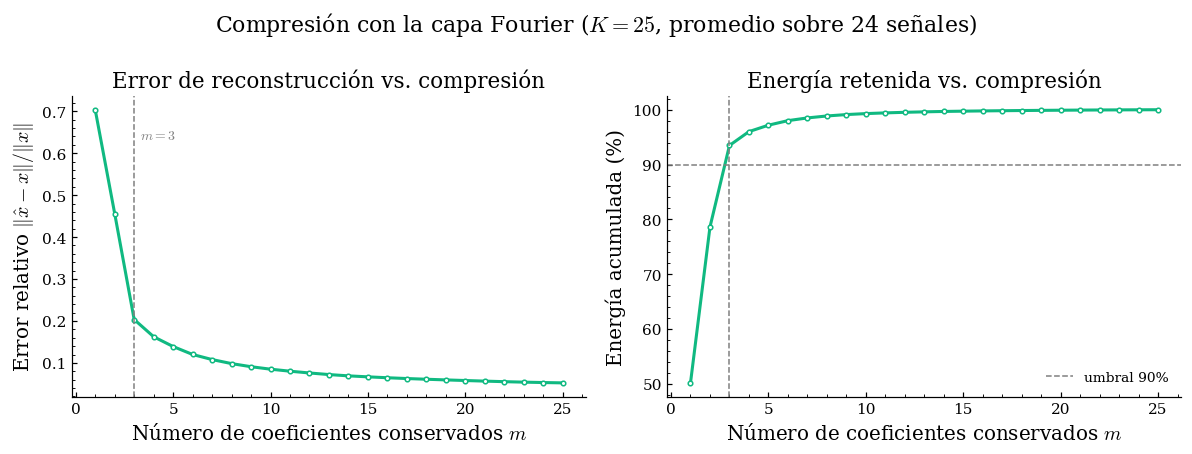

In [89]:
m_axis = np.arange(1, K + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ax1.plot(m_axis, error_medio, color=COL_G, lw=2, marker="o", ms=3, markerfacecolor="white")
ax1.axvline(m_umbral, color="gray", lw=1, ls="--")
ax1.text(m_umbral + 0.3, error_medio.max() * 0.9, f"$m={m_umbral}$", color="gray", fontsize=9)
ax1.set_xlabel("Número de coeficientes conservados $m$")
ax1.set_ylabel(r"Error relativo $\|\hat x - x\|/\|x\|$")
ax1.set_title("Error de reconstrucción vs. compresión")

ax2.plot(m_axis, energia_media_acum, color=COL_G, lw=2, marker="o", ms=3, markerfacecolor="white")
ax2.axhline(ENERGIA_UMBRAL, color="gray", lw=1, ls="--", label=f"umbral {ENERGIA_UMBRAL}%")
ax2.axvline(m_umbral, color="gray", lw=1, ls="--")
ax2.set_xlabel("Número de coeficientes conservados $m$")
ax2.set_ylabel("Energía acumulada (%)")
ax2.set_title("Energía retenida vs. compresión")
ax2.legend(frameon=False, fontsize=9)

fig.suptitle(f"Compresión con la capa Fourier ($K={K}$, promedio sobre {len(X)} señales)")
plt.tight_layout()
plt.show()
